roboflow dataset id - damage-b2vau
https://app.roboflow.com/surfacedetection-cauuh/damage-b2vau/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true

In [ ]:
import os
import zipfile
import shutil
import random

# CONFIG
zip_folder = "/content/zips"
output = "/content/final_dataset_split"
max_per_class = 1000

train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

# CREATE DIRS
for split in ["train", "val", "test"]:
    os.makedirs(f"{output}/{split}/images", exist_ok=True)
    os.makedirs(f"{output}/{split}/labels", exist_ok=True)

# INIT STORAGE
data_by_class = {i: [] for i in range(6)}

# UNZIP
extract_root = "/content/extracted"
os.makedirs(extract_root, exist_ok=True)

for z in os.listdir(zip_folder):
    if z.endswith(".zip"):
        full_path = os.path.join(zip_folder, z)
        print(f"📦 Extracting: {z}")
        with zipfile.ZipFile(full_path, 'r') as zip_ref:
            zip_ref.extractall(os.path.join(extract_root, z.replace(".zip","")))

print("✅ Unzipped")

# ===== CLASS MAPPING FUNCTION =====
def map_class(dataset_path, cls_id):
    path = dataset_path.lower()

    # crack dataset
    if "crack" in path:
        if cls_id in ["0","1","2"]:
            return 0
        elif cls_id == "3":
            return 1

    # corrosion
    elif "corrosion" in path:
        return 3

    # manhole
    elif "manhole" in path:
        return 2

    # pothole (FIXED)
    elif "pot" in path or "cap" in path or "road" in path:
        return 4

    # stain / humidity
    elif "humidity" in path or "stain" in path:
        return 5

    return None

# ===== COLLECT =====
for root, _, files in os.walk(extract_root):
    for file in files:
        if file.endswith(".txt"):
            label_path = os.path.join(root, file)

            with open(label_path) as f:
                lines = f.readlines()

            lines = [l.strip() for l in lines if l.strip()]
            if not lines:
                continue

            parts = lines[0].split()
            if not parts:
                continue

            cls_id = parts[0]

            new_cls = map_class(root, cls_id)

            if new_cls is not None:
                data_by_class[new_cls].append((label_path, root))

# ===== BALANCE PER CLASS =====
for cls in data_by_class:
    items = data_by_class[cls]
    if len(items) > max_per_class:
        data_by_class[cls] = random.sample(items, max_per_class)

# ===== PRINT CLASS COUNTS =====
print("\n📊 Class counts after balancing:")
for cls, items in data_by_class.items():
    print(f"Class {cls}: {len(items)}")

# ===== SPLIT PER CLASS =====
splits = {"train": [], "val": [], "test": []}

for cls, items in data_by_class.items():
    random.shuffle(items)

    total = len(items)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    splits["train"].extend(items[:train_end])
    splits["val"].extend(items[train_end:val_end])
    splits["test"].extend(items[val_end:])

# ===== PRINT SPLIT =====
print("\n📦 Split sizes:")
for k in splits:
    print(f"{k}: {len(splits[k])}")

# ===== COPY + MODIFY =====
counters = {"train":0, "val":0, "test":0}

for split, items in splits.items():
    for label_path, root in items:

        filename = os.path.basename(label_path)

        # find image
        img_path = None
        for ext in [".jpg",".png",".jpeg"]:
            temp = os.path.join(root.replace("labels","images"), filename.replace(".txt", ext))
            if os.path.exists(temp):
                img_path = temp
                break

        if img_path is None:
            continue

        with open(label_path) as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            if not line.strip():
                continue

            parts = line.split()
            if not parts:
                continue

            cls_id = parts[0]
            new_cls = map_class(root, cls_id)

            if new_cls is not None:
                parts[0] = str(new_cls)
                new_lines.append(" ".join(parts))

        count = counters[split]

        shutil.copy(img_path, f"{output}/{split}/images/{count}.jpg")

        with open(f"{output}/{split}/labels/{count}.txt","w") as f:
            f.write("\n".join(new_lines))

        counters[split] += 1

print("\n🚀 DONE!")

In [ ]:
from ultralytics import YOLO

# Load model
model = YOLO("yolo26s-seg.pt")

# Train
results = model.train(
    data="/content/crack_dataset2/data.yaml",
    epochs=10,
    imgsz=512,
    project="/content/crack_project",
    name="yolo_model"
)

# Path of best model
best_model_path = "/content/crack_project/yoloe_model/weights/best.pt"

print("Best model saved at:", best_model_path)

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/crack_project/yolo_model2/weights/best.pt")

In [ ]:
results = model.predict(
    source="/content/crack_dataset2/test/images",
    save=True
)

# Show first result
print(results[0].masks)

Selected bbox: [65, 121, 543, 553]


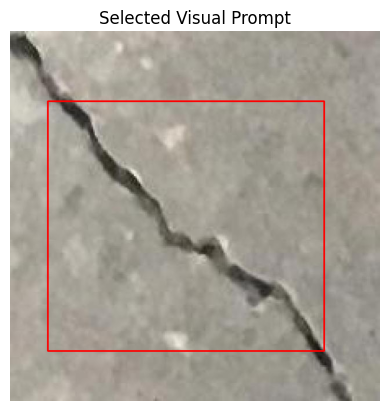

In [5]:
import cv2
import matplotlib.pyplot as plt

img_path = "test/images/00030_jpg.rf.3d3656c8def8ca2d83a528bff732a62a.jpg"  # 👈 change this
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Select ROI (interactive)
bbox = cv2.selectROI("Select Object", img, False)
cv2.destroyAllWindows()

x, y, w, h = bbox

# convert to x1,y1,x2,y2
x1, y1, x2, y2 = x, y, x+w, y+h

print("Selected bbox:", [x1, y1, x2, y2])

# show selected bbox
img_copy = img_rgb.copy()
cv2.rectangle(img_copy, (x1,y1), (x2,y2), (255,0,0), 2)

plt.imshow(img_copy)
plt.title("Selected Visual Prompt")
plt.axis("off")
plt.show()

In [9]:
import numpy as np
from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor
# load model
model = YOLOE("yoloe-26s-seg.pt")

# create visual prompt
visual_prompts = dict(
    bboxes=np.array([[x1, y1, x2, y2]]),
    cls=np.array([0])   # 👈 assign class id
)

# run prediction
results = model.predict(
    source=img_path,
    visual_prompts=visual_prompts,
    predictor=YOLOEVPSegPredictor
)

# show result
results[0].show()

AttributeError: Can't get attribute 'YOLOESegment26' on <module 'ultralytics.nn.modules.head' from 'c:\\Users\\HP\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\ultralytics\\nn\\modules\\head.py'>

In [1]:
print("hello")

hello
